# Parsing und Exploration der DNB-Hochschulschriften


## 1. Import und Setup

In [1]:
# Pfad zum src-Ordner hinzufügen
import sys
from pathlib import Path

# Projektroot ermitteln (eine Ebene über notebooks/)
project_root = Path().resolve().parent
src_path = project_root / "src"
sys.path.append(str(src_path))

print("src-Pfad hinzugefügt:", src_path)


src-Pfad hinzugefügt: /Users/AS/Desktop/Portfolio/dnb-marc21-theses/src


In [2]:
# Eigene Module
from core.marc21_parser import parse_dnb_theses
from core.data_explorer import Marc21Explorer

# Standardbibliotheken
import pandas as pd
from collections import Counter
from pathlib import Path

# Datenanalyse
from IPython.display import display

# Visualisierung
import matplotlib.pyplot as plt
import seaborn as sns  # optional, für schönere Plots

# Anzeigeoptionen
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 100)
sns.set_theme(style="whitegrid")

## 2. Daten einlesen und speichern

### 2.1 Auswahl der Datensätze
NB: Am 12.02.2026 Total records parsed: 1619129 in 10min+, am 16.02. in 8m 20.6s

In [17]:
# --- Relativer Pfad zur Datei im Repository ---
data_file = Path("../data/raw/dnb-all_hochschulschriften_dnbmarc.mrc.xml")

# --- Prüfen, ob die Datei existiert ---
if not data_file.exists():
    print("Die MARC21-Datei wurde nicht gefunden!")
    print("Bitte lade die Datei von DNB Lab herunter:")
    print("https://www.dnb.de/dnblabdatendiss")
    #print(f"Speichere sie hier: {data_file.resolve()}")
else:
    # --- Parser aufrufen ---
    df = parse_dnb_theses(
        filepath=str(data_file),
        limit=100000,   # optional, z.B. zum Testen
        verbose=True
    )
    print("Datei geladen!") 


Parsed 1000 records...
Parsed 2000 records...
Parsed 3000 records...
Parsed 4000 records...
Parsed 5000 records...
Parsed 6000 records...
Parsed 7000 records...
Parsed 8000 records...
Parsed 9000 records...
Parsed 10000 records...
Parsed 11000 records...
Parsed 12000 records...
Parsed 13000 records...
Parsed 14000 records...
Parsed 15000 records...
Parsed 16000 records...
Parsed 17000 records...
Parsed 18000 records...
Parsed 19000 records...
Parsed 20000 records...
Parsed 21000 records...
Parsed 22000 records...
Parsed 23000 records...
Parsed 24000 records...
Parsed 25000 records...
Parsed 26000 records...
Parsed 27000 records...
Parsed 28000 records...
Parsed 29000 records...
Parsed 30000 records...
Parsed 31000 records...
Parsed 32000 records...
Parsed 33000 records...
Parsed 34000 records...
Parsed 35000 records...
Parsed 36000 records...
Parsed 37000 records...
Parsed 38000 records...
Parsed 39000 records...
Parsed 40000 records...
Parsed 41000 records...
Parsed 42000 records...
P

In [4]:
  # --- Erste Übersicht ---
display(df.head().T)
print(df.info())

,0,1,2,3,4
record_id,200046810,200147609,200155547,200238019,200241982
control_008,941115s1974 gw ||||| m||| 00||||ger,941115s1974 gw ||||| m||| 00||||ger,941115s1973 gw ||||| m||| 00||||ger,941115s1974 gw ||||| m||| 00||||ger,941115s1974 gw ||||| m||| 00||||ger
author_name,"Lippert, Jörg","Schneider, Dieter Marc","Polivka, Heinz","Fravi, Paul","Bürge, Alfons"
author_dates,,,1934-,,1947-
author_gnd,1055797971,,1099475023,126324522,170727785
title,Beiträge zu Technik und Syntax althochdeutsche Übersetzungen,Revolutionärer Syndikalismus und Bolschewismus,Die chemische Industrie im Raume von Basel,Schloß Baldenstein,Die Juristenkomik in Ciceros Rede Pro Murena
title_remainder,unter bes. Berücks. d. Isidorgruppe u. d. althochdt. Tatian,d. Prozeß d. ideolog. Auseinandersetzung franz. Syndikalisten mit d. Bolschewiki 1914-1922,,d. Geschichte e. bündner. Herrschaftssitzes u. seiner Bewohner,Übers. u. Kommentar
publication_place,,,,Zürich,Zürich
publisher,,,,Juris Druck Verlag,Juris Druck & Verlag
publication_year,,,,1974,1974


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   record_id          100000 non-null  object
 1   control_008        100000 non-null  object
 2   author_name        100000 non-null  object
 3   author_dates       100000 non-null  object
 4   author_gnd         100000 non-null  object
 5   title              100000 non-null  object
 6   title_remainder    100000 non-null  object
 7   publication_place  100000 non-null  object
 8   publisher          100000 non-null  object
 9   publication_year   100000 non-null  object
 10  dissertation_note  100000 non-null  object
 11  084_list           100000 non-null  object
 12  083_list           100000 non-null  object
 13  082_list           100000 non-null  object
 14  490_list           100000 non-null  object
 15  648_list           100000 non-null  object
 16  650_list           10

### 2.2 Speichern

In [7]:
# --- Parquet-Pfad ---
# parquet_file = Path("../data/raw/dnb_theses.parquet")

# --- DataFrame speichern ---
# df.to_parquet(parquet_file, engine="pyarrow", compression="snappy")
# print(f"DataFrame gespeichert als: {parquet_file.resolve()}")

# --- Für zukünftige Notebooks: nur Parquet laden ---
# df = pd.read_parquet(parquet_file)


In [8]:
#import sys
#print(sys.executable)

#import pyarrow
#print(pyarrow.__version__)

In [18]:
# --- Optional: Als CSV speichern ---
# csv_file = Path("../data/raw/dnb_theses.csv")
##csv_file.parent.mkdir(parents=True, exist_ok=True)
# df.to_csv(csv_file, index=False, encoding='utf-8')
# print(f"DataFrame als CSV gespeichert: {csv_file.resolve()}")

DataFrame als CSV gespeichert: /Users/AS/Desktop/Portfolio/dnb-marc21-theses/data/raw/dnb_theses.csv


## 3. Datenanalyse

In [10]:
# --- Für zukünftige Notebooks: nur Parquet laden ---
# df = pd.read_parquet(parquet_file)

In [19]:
# Explorer initialisieren
explorer = Marc21Explorer(df)

In [21]:
# Test, ob Listen in DataFrame-Zellen korrekt gespeichert wurden
print("Datentyp der 084_list-Zelle:", type(explorer.df["084_list"].iloc[3]))

# wenn String, dann mit json.loads() zurück in Liste umwandeln
# dann in der Explorer-Klasse anpassen, damit das automatisch passiert

Datentyp der 084_list-Zelle: <class 'list'>


In [22]:
# Übersicht über die Spalten 
display(explorer.overview(max_elements_preview=3))

# Fehlende Werte
missing = explorer.missing_report()
display(missing)

,dtype,non_null,missing_n,missing_%,uniques_n,uniques_preview
record_id,object,1619129,0,0.0,1619129,"[200046810, 200147609, 200155547, ... (+1619126)]"
control_008,object,1619129,0,0.0,139147,"[941115s1974 gw ||||| m||| 00||||ger, 941115s1973 gw ||||| m||| 00||||ger, 941116s ..."
author_name,object,1619129,0,0.0,1165017,"[Lippert, Jörg, Schneider, Dieter Marc, Polivka, Heinz, ... (+1165014)]"
author_dates,object,1619129,0,0.0,4951,"[, 1934-, 1947-, ... (+4948)]"
author_gnd,object,1619129,0,0.0,836357,"[1055797971, , 1099475023, ... (+836354)]"
title,object,1619129,0,0.0,1448102,"[Beiträge zu Technik und Syntax althochdeutsche Übersetzungen, Revolutionärer Syndikalismus u..."
title_remainder,object,1619129,0,0.0,384204,"[unter bes. Berücks. d. Isidorgruppe u. d. althochdt. Tatian, d. Prozeß d. ideolog. Auseinander..."
publication_place,object,1619129,0,0.0,9494,"[, Zürich, Frankfurt am Main, ... (+9491)]"
publisher,object,1619129,0,0.0,21566,"[, Juris Druck Verlag, Juris Druck & Verlag, ... (+21563)]"
publication_year,object,1619129,0,0.0,5429,"[, 1974, 1975, ... (+5426)]"


KeyboardInterrupt: 

### 3.1 Klassifizierung

In [23]:
# Relevante MARC-Felder
marc_list_fields = ["084_list", "083_list", "082_list"]

total_records = len(df)

for field in marc_list_fields:
    if field in df.columns:
        # Zählen, wie viele Zellen nicht leer sind (Liste enthält mindestens ein Element)
        count_non_empty = df[field].dropna().apply(lambda x: len(x) > 0).sum()
        percent = (count_non_empty / total_records) * 100
        print(f"{field}: {count_non_empty}/{total_records} Datensätze ({percent:.1f}%) mit Einträgen")

# 084_list: 747468/1619129 Datensätze (46.2%) mit Einträgen
# 083_list: 549580/1619129 Datensätze (33.9%) mit Einträgen
# 082_list: 812149/1619129 Datensätze (50.2%) mit Einträgen

084_list: 747468/1619129 Datensätze (46.2%) mit Einträgen
083_list: 549580/1619129 Datensätze (33.9%) mit Einträgen
082_list: 812149/1619129 Datensätze (50.2%) mit Einträgen


In [24]:
# Liste für die aufgeteilten Daten
data = []

# Durch alle Datensätze gehen
for recs in df['084_list'].dropna():  # alle nicht-leeren Zellen
    if isinstance(recs, list):
        for subfield_dict in recs:
            a_value = subfield_dict.get('a')
            if a_value:
                # Aufteilen, falls mehrere Codes in einem String (getrennt durch ';')
                codes = [code.strip() for code in a_value.split(';')]
                for code in codes:
                    data.append({
                        'a': code,
                        'q': subfield_dict.get('q'),
                        '2': subfield_dict.get('2')
                    })

# In DataFrame umwandeln
df_084 = pd.DataFrame(data)

# Überblick
print("Beispielhafte Vorschau auf die Daten:")
print(df_084.head())

# Anzahl der Datensätze nach Vergabestelle oder Quelle zählen
print("\nAnzahl der Notationen pro Vergabestelle (q):")
print(df_084['q'].value_counts())

print("\nAnzahl der Notationen pro Quelle (2):")
print(df_084['2'].value_counts())


Beispielhafte Vorschau auf die Daten:
      a       q     2
0  1701  DE-101  sdnb
1   900  DE-101  sdnb
2   920  DE-101  sdnb
3   940  DE-101  sdnb
4   943  DE-101  sdnb

Anzahl der Notationen pro Vergabestelle (q):
q
DE-101    3228921
DE-30         368
DE-3          152
DE-1a          57
DE-21          27
DE-12          23
DE-5            6
DE-16           5
DE-11           4
DE-84           4
DE-105          3
DE-7            3
DE-210          2
DE-23           2
DE-6            1
Name: count, dtype: int64

Anzahl der Notationen pro Quelle (2):
2
sdnb       2634499
sswd        599481
ddc          94564
rvk          40374
bkl          12774
bcl           7552
ssgn          2431
lcc           2023
fid            674
stub           530
z              394
jelc           221
rpb            207
msc            130
udc            121
sbb            111
sfb             61
ifzs            38
bisacsh         32
nwbib           27
kktb            23
cjurrom          4
njb              2
Name: co

In [10]:
# Gesamtanzahl aller Notationen
total_notations = len(df_084)

# Top 10 Notationen
top_10 = df_084['a'].value_counts().head(10)

# Ausgabe mit Anzahl und prozentualem Anteil
print("Top 10 Notationen in 084_list $a:")
for code, count in top_10.items():
    percent = (count / total_notations) * 100
    print(f"{code}: {count} ({percent:.1f}%)")

 # Achtung irreführend, weil verschiedene Notationssysteme (Dewey, RVK, LCC) in einem Feld vermischt sein können.   


Top 10 Notationen in 084_list $a:
610: 30438 (27.0%)
33: 27663 (24.5%)
620: 3145 (2.8%)
1501: 2283 (2.0%)
330: 1810 (1.6%)
0400: 1325 (1.2%)
540: 1321 (1.2%)
0300: 1304 (1.2%)
530: 1294 (1.1%)
510: 1294 (1.1%)


In [25]:
# Dataframe mit aufgeteilten Feldern vorbereiten
marc_list_fields = ["082_list", "083_list", "084_list"]

# Hilfsfunktion, um $a, $q, $2 aus einem list[dict] zu extrahieren
def extract_subfields(sublist, subfields=['a','q','2']):
    if sublist is None or not isinstance(sublist, list) or len(sublist) == 0:
        return {f: None for f in subfields}
    
    result = {f: [] for f in subfields}
    for entry in sublist:
        for f in subfields:
            if f in entry and entry[f]:
                # Trennen, falls mehrere Codes in $a z. B. "1701 ; 900"
                if f == 'a' and ';' in entry[f]:
                    codes = [c.strip() for c in entry[f].split(';')]
                    result[f].extend(codes)
                else:
                    result[f].append(entry[f])
    # Falls leere Liste → None
    for f in subfields:
        if not result[f]:
            result[f] = None
    return result

# Neues DataFrame vorbereiten
data = []

for idx, row in df.iterrows():
    new_row = {'record_id': row['record_id']}
    
    # 082
    if '082_list' in df.columns:
        extracted = extract_subfields(row.get('082_list'))
        new_row['082_a'] = extracted['a']
        new_row['082_q'] = extracted['q']
        new_row['082_2'] = extracted['2']
    
    # 083
    if '083_list' in df.columns:
        extracted = extract_subfields(row.get('083_list'))
        new_row['083_a'] = extracted['a']
        new_row['083_q'] = extracted['q']
        new_row['083_2'] = extracted['2']
    
    # 084
    if '084_list' in df.columns:
        extracted = extract_subfields(row.get('084_list'))
        new_row['084_a'] = extracted['a']
        new_row['084_q'] = extracted['q']
        new_row['084_2'] = extracted['2']
    
    data.append(new_row)

df_flat = pd.DataFrame(data)



Vorschau auf flaches DataFrame:


,record_id,082_a,082_q,082_2,083_a,083_q,083_2,084_a,084_q,084_2
0,200046810,None,None,None,None,None,None,None,None,None
1,200147609,None,None,None,None,None,None,None,None,None
2,200155547,None,None,None,None,None,None,None,None,None
3,200238019,None,None,None,None,None,None,"[1701, 900, 920, 940, 943, 950, 960, 970, 980, 990]",[DE-101],[sdnb]
4,200241982,None,None,None,None,None,None,"[2000, 320, 340, 350]",[DE-101],[sdnb]


In [27]:
df_flat


,record_id,082_a,082_q,082_2,083_a,083_q,083_2,084_a,084_q,084_2
0,200046810,None,None,None,None,None,None,None,None,None
1,200147609,None,None,None,None,None,None,None,None,None
2,200155547,None,None,None,None,None,None,None,None,None
3,200238019,None,None,None,None,None,None,"[1701, 900, 920, 940, 943, 950, 960, 970, 980, 990]",[DE-101],[sdnb]
4,200241982,None,None,None,None,None,None,"[2000, 320, 340, 350]",[DE-101],[sdnb]
...,...,...,...,...,...,...,...,...,...,...
1619124,1202547486,"[891.8, 700, 100]",[DE-101],[23sdnb],[800],[DE-600],[23sdnb],None,None,None
1619125,1269519336,"[943, 930]",[DE-101],[23sdnb],"[943, 930]",[DE-600],[23sdnb],None,None,None
1619126,011157429,[370],[DE-101],[22sdnb],[370],[DE-600],[22sdnb],"[5,3, DA 1000]",None,"[ssgn, rvk]"
1619127,012830461,[943],[DE-101],[22sdnb],"[900, 001.09, 306.09, 060]",[DE-600],"[22/BSB, 22/BSB, 22/BSB, 22sdnb]","[8,1]",None,[ssgn]


Top 10 SDNB-Notationen in 084_list $a mit Bedeutungen und Prozent:
610: 298140 (9.2%) – Bauwesen / Architektur
33: 249265 (7.7%) – Politik / Staatswissenschaften
32: 64684 (2.0%) – Unbekannt
670: 64425 (2.0%) – Unbekannt
30: 59487 (1.8%) – Unbekannt
17a: 54158 (1.7%) – Unbekannt
530: 53122 (1.6%) – Physik
520: 53053 (1.6%) – Unbekannt
540: 51494 (1.6%) – Chemie
570: 49509 (1.5%) – Unbekannt


/var/folders/xg/jr6j_719197b8r74d8xx0yl80000gn/T/ipykernel_23460/617119577.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_counts, y=top_meanings, palette="viridis")


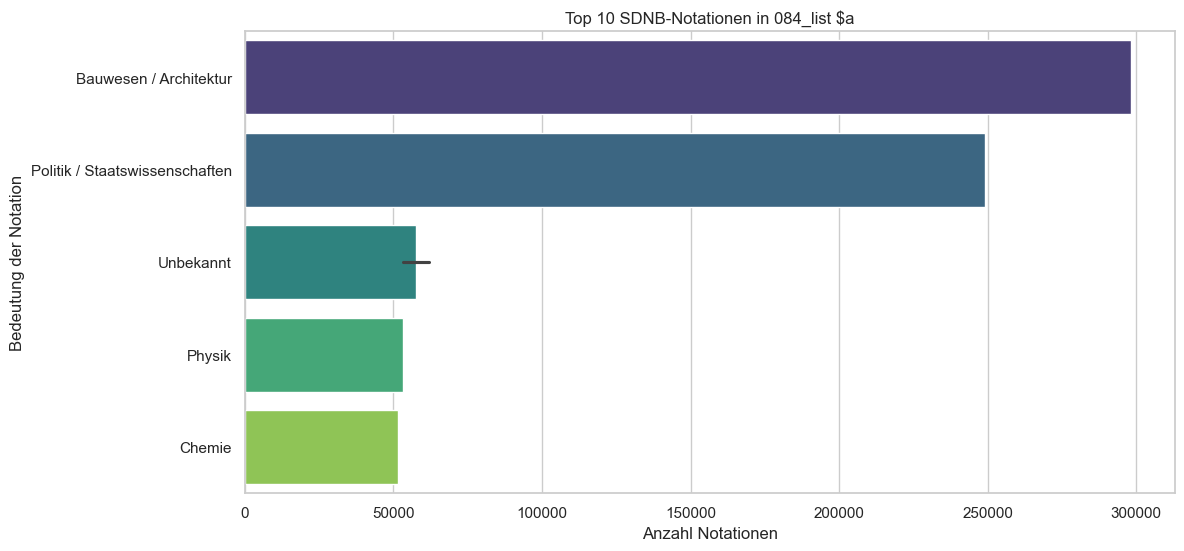


Anzahl Datensätze pro Quelle in 084_list:
sdnb: 664410
sswd: 191329
ddc: 91484
rvk: 37715
lcc: 1981
bcl: 7552
bkl: 12774
z: 361
sfb: 57
msc: 120
jelc: 41
stub: 524
sbb: 106
udc: 121
ssgn: 2152
bisacsh: 29
kktb: 23
fid: 674
cjurrom: 4
njb: 2
rpb: 118
ifzs: 22
nwbib: 27


/var/folders/xg/jr6j_719197b8r74d8xx0yl80000gn/T/ipykernel_23460/617119577.py:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(source_counts.keys()), y=list(source_counts.values()), palette="magma")


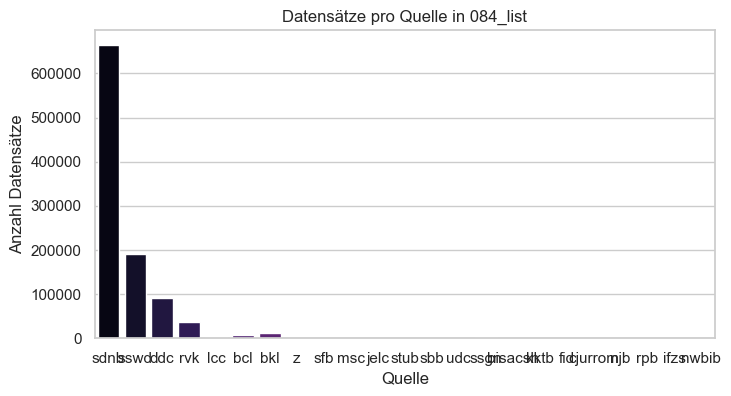

In [ ]:

# Beispiel-Notation-Dictionary (kann beliebig erweitert werden)
notation_dict = {
    "1701": "Allgemeine Geschichte",
    "900": "Rechtswissenschaften",
    "920": "Philosophie",
    "940": "Theologie",
    "943": "Geschichte Deutschlands",
    "950": "Naturwissenschaften",
    "960": "Technik",
    "970": "Kunst",
    "980": "Musik",
    "990": "Literatur",
    "2000": "Technik / Ingenieurwesen",
    "320": "Politik / Staatswissenschaften",
    "340": "Recht / Gesetzgebung",
    "330": "Soziologie / Sozialwissenschaften",
    "0300": "Geographie / Kartographie",
    "0400": "Bibliothekswesen / Dokumentation",
    "510": "Mathematik",
    "530": "Physik",
    "540": "Chemie",
    "610": "Bauwesen / Architektur",
    "620": "Maschinenbau",
    "33": "Politik / Staatswissenschaften",
    "1501": "Geschichte Deutschlands",
    # ... erweitern je nach Bedarf
}

# 1️⃣ SDNB-Datensätze filtern
df_sdnb = df_flat[df_flat['084_2'].apply(lambda x: isinstance(x, list) and 'sdnb' in x)]

# 2️⃣ Alle 084_a flatten
all_codes = []
for codes in df_sdnb['084_a'].dropna():
    all_codes.extend(codes)

# 3️⃣ Häufigkeiten zählen
counter = Counter(all_codes)
total_codes = sum(counter.values())
top_10 = counter.most_common(10)

# 4️⃣ Ausgabe mit Bedeutungen und Prozent
print("Top 10 SDNB-Notationen in 084_list $a mit Bedeutungen und Prozent:")
for code, count in top_10:
    meaning = notation_dict.get(code, "Unbekannt")
    percent = (count / total_codes) * 100
    print(f"{code}: {count} ({percent:.1f}%) – {meaning}")

# 5️⃣ Visualisierung Top-10
top_codes = [c for c, _ in top_10]
top_counts = [c for _, c in top_10]
top_meanings = [notation_dict.get(c, "Unbekannt") for c in top_codes]

plt.figure(figsize=(12,6))
sns.barplot(x=top_counts, y=top_meanings, palette="viridis")
plt.xlabel("Anzahl Notationen")
plt.ylabel("Bedeutung der Notation")
plt.title("Top 10 SDNB-Notationen in 084_list $a")
plt.show()

# 6️⃣ Vergleich der Anzahl Datensätze pro Quelle in 084_2
# flatten alle Quellen
all_sources = []
for sources in df_flat['084_2'].dropna():
    all_sources.extend(sources)

source_counts = Counter(all_sources)
print("\nAnzahl Datensätze pro Quelle in 084_list:")
for src, count in source_counts.items():
    print(f"{src}: {count}")

# Optional: Visualisierung Quellen
plt.figure(figsize=(8,4))
sns.barplot(x=list(source_counts.keys()), y=list(source_counts.values()), palette="magma")
plt.ylabel("Anzahl Datensätze")
plt.xlabel("Quelle")
plt.title("Datensätze pro Quelle in 084_list")
plt.show()


### 3.2 Dissertationsvermerk

In [33]:
def count_dissertation_notes(df: pd.DataFrame) -> int:
    """
    Zählt die Datensätze in 'dissertation_note', die nicht leer sind.
    """
    return df["dissertation_note"].apply(lambda x: bool(str(x).strip())).sum()


In [34]:
def dissertation_note_overview(df: pd.DataFrame) -> pd.DataFrame:
    """
    Übersicht über vorhandene / fehlende Dissertationseinträge.
    """
    total = len(df)

    def has_note(x):
        if pd.isna(x):
            return False
        if isinstance(x, str) and x.strip() == "":
            return False
        return True

    num_with_entry = df["dissertation_note"].apply(has_note).sum()
    num_empty = total - num_with_entry

    return pd.DataFrame({
        "category": ["Mit Dissertationseintrag", "Ohne Dissertationseintrag"],
        "count": [num_with_entry, num_empty],
        "percent": [round(num_with_entry/total*100,1), round(num_empty/total*100,1)]
    })


In [35]:
overview = dissertation_note_overview(df)
print(overview)


                    category    count  percent
0   Mit Dissertationseintrag  1250895     77.3
1  Ohne Dissertationseintrag   368234     22.7


                    category    count  percent
0   Mit Dissertationseintrag  1250895     77.3
1  Ohne Dissertationseintrag   368234     22.7


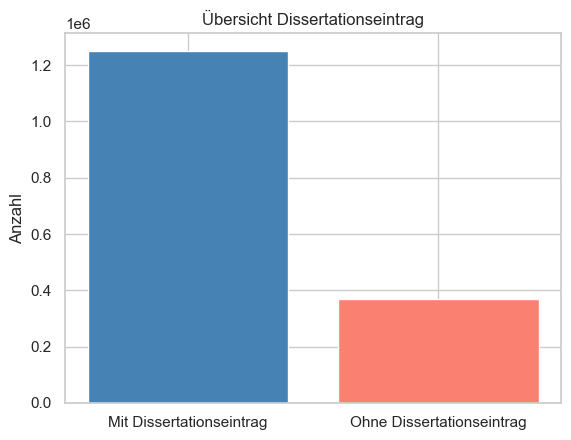

In [36]:
# Übersicht erstellen
overview = dissertation_note_overview(df)
print(overview)

# Plot
categories = overview["category"]
counts = overview["count"]

plt.bar(categories, counts, color=['steelblue', 'salmon'])
plt.ylabel('Anzahl')
plt.title('Übersicht Dissertationseintrag')
plt.show()


In [37]:
# Extraktion der Promotionsjahre
df["promotionsjahr"] = df["dissertation_note"].str.extract(r"(\d{4})")

# Überprüfen, ob die Extraktion funktioniert hat
print(df[["dissertation_note"]].head(10))

                                                                                   dissertation_note
0            Marburg, Univ., Diss., Philos. Fak., Diss. 1970. - Nicht für d. Aust. - Zugl im Buchh.
1  Erlangen-Nürnberg, Univ., Philos. Fak., Diss. 1973. - Nicht für d. Austausch. - Zugl. im Buchh.
2                                     Basel, Univ., Philos.-naturwiss. Fak., Diss. - Zugl. im Buchh.
3                                                                       Zugl.: Zürich, Univ., Diss.
4                                                                       Zugl.: Zürich, Univ., Diss.
5                                                             Zugl.: Frankfurt am Main, Univ., Diss.
6                                                                   Zugl.: Lund, Univ., Diss., 1974.
7                                                                Zugl.: Zürich, Univ., Diss., 1973.
8                                                                    Zugl.: Göttingen, Uni

In [40]:
# Zählen, wie viele Datensätze 'Fak.' enthalten
anzahl_fak = df["dissertation_note"].str.contains("Fak", case=False, na=False).sum()
gesamt = len(df)

print(f"Anzahl der Datensätze mit 'Fak': {anzahl_fak} von insgesamt {gesamt} Titeln")

Anzahl der Datensätze mit 'Fak': 95850 von insgesamt 1619129 Titeln


### 3.3 Zeitliche Entwicklung

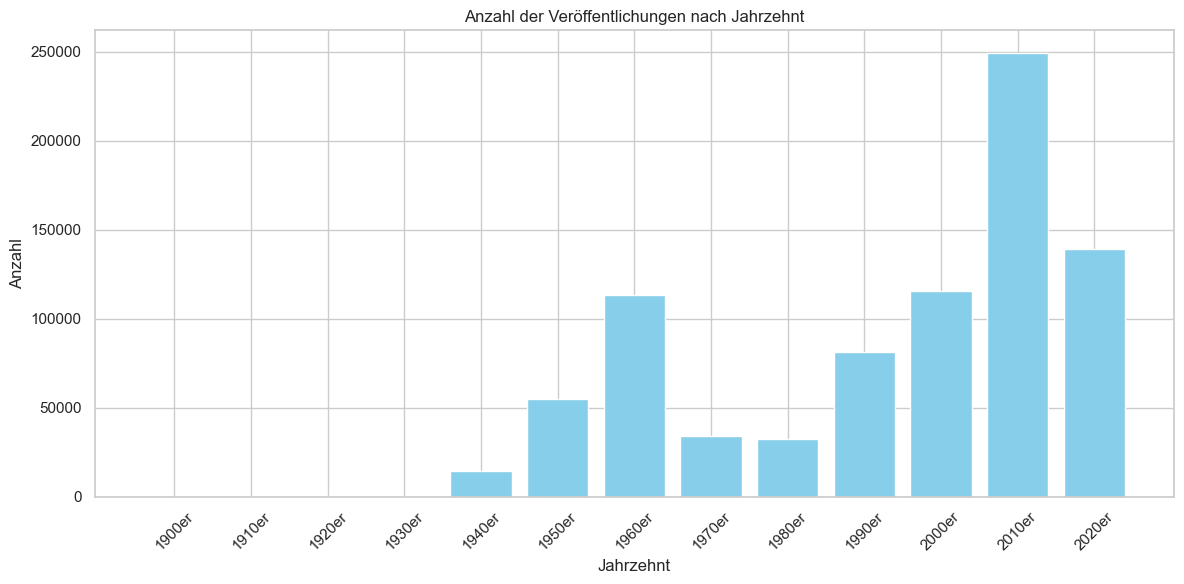

In [50]:
# 1. In Zahlen umwandeln, fehlerhafte Werte -> NaN
df["publication_year"] = pd.to_numeric(df["publication_year"], errors="coerce")

# 2. Nur plausible Jahre behalten (NaN wird automatisch entfernt)
df_filtered = df["publication_year"][(df["publication_year"] >= 1900) & (df["publication_year"] <= 2026)]

# 3. Jahr-Häufigkeiten zählen
year_counts = df_filtered.value_counts().sort_index()

# 4. Jahre in Jahrzehnte umwandeln und summieren
decade_counts = year_counts.groupby((year_counts.index // 10) * 10).sum()

# 5. Nur Jahrzehnte mit mindestens einer Publikation behalten
decade_counts = decade_counts[decade_counts > 0]

# 6. Plot
plt.figure(figsize=(12, 6))
plt.bar(
    x=[f"{int(d)}er" for d in decade_counts.index],  # schöne Labels
    height=decade_counts.values,
    color='skyblue'
)
plt.title('Anzahl der Veröffentlichungen nach Jahrzehnt')
plt.xlabel('Jahrzehnt')
plt.ylabel('Anzahl')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [48]:
# Jahr prüfen
def check_year(year, df):
    """
    Prüft, ob ein Jahr in df['publication_year'] enthalten ist.
    Gibt die Zeilen mit diesem Jahr zurück.
    """
    if year in df["publication_year"].values:
        print(f"{year} ist in df['publication_year'] enthalten")
        # Zeilen mit diesem Jahr ausgeben
        print(df[df["publication_year"] == year])
    else:
        print(f"{year} ist nicht in df['publication_year'] enthalten")

# Beispiele:
check_year(1945, df)


1945 ist nicht in df['publication_year'] enthalten


### 3.4 Schlagwörter/Themen

In [51]:
# Liste der Spalten, die Schlagwörter enthalten
keyword_columns = ['648_list', '650_list', '830_list']

# Anzahl Schlagwörter pro Zeile berechnen
df['subject_count'] = df[keyword_columns].apply(lambda row: sum(bool(x) for x in row), axis=1)

# Statistik ausgeben
subject_stats = df['subject_count']
print(f"Durchschnittliche Anzahl Schlagwörter: {subject_stats.mean():.2f}")
print(f"Median der Schlagwörter: {subject_stats.median():.0f}")
print(f"Maximale Anzahl Schlagwörter: {subject_stats.max():.0f}")
print(f"Minimale Anzahl Schlagwörter: {subject_stats.min():.0f}")
   

Durchschnittliche Anzahl Schlagwörter: 0.69
Median der Schlagwörter: 1
Maximale Anzahl Schlagwörter: 3
Minimale Anzahl Schlagwörter: 0


## 4. Daten filtern

In [52]:
# Sicherstellen, dass publication_year numerisch ist
df['publication_year'] = pd.to_numeric(df['publication_year'], errors='coerce')

# --- Einzelnes Jahr ---
jahr = 1939
df_filtered = df[df['publication_year'] == jahr]
print(f"Dissertationen aus dem Jahr {jahr}: {len(df_filtered)}")

# --- Liste von Jahren ---
jahre_liste = [1955, 1956, 1958]
df_filtered = df[df['publication_year'].isin(jahre_liste)]
print(f"Dissertationen aus den Jahren {jahre_liste}: {len(df_filtered)}")

# --- Jahrbereich ---
start_jahr = 1913
end_jahr = 1939
df_filtered = df[(df['publication_year'] >= start_jahr) & (df['publication_year'] <= end_jahr)]
print(f"Dissertationen von {start_jahr} bis {end_jahr}: {len(df_filtered)}")


Dissertationen aus dem Jahr 1939: 34
Dissertationen aus den Jahren [1955, 1956, 1958]: 16449
Dissertationen von 1913 bis 1939: 951


In [53]:
# Beispiel: Dissertationen aus Leipzig
df_leipzig = df[df['publication_place'].str.contains('Leipzig', na=False, case=False)]
print(f"Dissertationen aus Leipzig: {len(df_leipzig)}")
df_leipzig[['author_name', 'title', 'publication_year']].head(10)

Dissertationen aus Leipzig: 21107


,author_name,title,publication_year
182,"Herz, Gerhard",Johann Sebastian Bach im Zeitalter des Rationalismus und der Frühromantik,1985.0
396,"Sommerburg, Herbert",Versuche der Nutzung vorhandener Meßergebnisse für Untersuchungen über den Einfluß der Arbeits...,1976.0
13763,"Hartung, Fritz",Untersuchungen über Trainingseinwirkungen am jugendlichen Organismus zur Feststellung der Train...,1959.0
14063,"Bley, Horst",Die Berufsbildung und ihre weitere Entwicklung,1961.0
20742,"Perina, Lilith","Untersuchungen über die Möglichkeit der Ernährung und Diättherapie mit Hilfe ""verpilzter"" Ge...",NaN
20958,"Noeske, Klaus",Über die arterielle Versorgung des menschlichen Rückenmarkes,NaN
20968,"Roll, Dieter",Über die Arterien der Pars caudalis des menschlichen Rückenmarkes und das Vorkommen arterio-ve...,NaN
21453,"Rose, Eckart",Spannungszusammenbruch an schnellen Funken,NaN
21817,"Hinkel, Ilse",Über die Klinik der Ostitis fibrosa localisata,1959.0
22159,"Gress, Maria",Der Einfluß des Plasmas und einer geringen Änderung des Genoms auf die Affinität zwischen Sa...,1959.0


## 5. Erweiterte Analyse: Titel

In [54]:
# Titel-Längen analysieren
df['title_length'] = df['title'].str.len()
print(f"Durchschnittliche Titel-Länge: {df['title_length'].mean():.0f} Zeichen")
print(f"Längster Titel: {df['title_length'].max():.0f} Zeichen")
print(f"Kürzester Titel: {df['title_length'].min():.0f} Zeichen")

Durchschnittliche Titel-Länge: 87 Zeichen
Längster Titel: 601 Zeichen
Kürzester Titel: 1 Zeichen


In [ ]:
# Längster Titel anzeigen
# longest_title = df.loc[df['title_length'].idxmax()]
# print("Längster Titel:")
# print(f"Autor: {longest_title['author_name']}")
# print(f"Titel: {longest_title['title']}")
# print(f"Jahr: {longest_title['publication_year']}")

Längster Titel:
Autor: Möhr, Markus
Titel: Die Kognition des Bundesgerichts bei der Überprüfung der Anwendung des kantonalen Gesetzesrechts im Rahmen der staatsrechtlichen Beschwerde wegen Verletzung verfassungsmäßiger Freiheitsrechte, insbesondere der Handels- und Gewerbefreiheit und der persönlichen Freiheit
Jahr: 1984.0


In [57]:
# Suchbegriff: Mineralog*
search_term = "Mineralog"

# Filtere nach 'title' oder 'title_remainder'
filtered_df = df[
    df['title'].str.contains(search_term, case=False, regex=True) |
    df['title_remainder'].str.contains(search_term, case=False, regex=True)
]

# Optional: nur bestimmte Spalten anzeigen
result_df = filtered_df[['author_name', 'title', 'title_remainder', 'publication_year']].copy()

# Anzahl der Treffer ausgeben
num_results = len(result_df)
print(f"Anzahl gefundener Titel mit '{search_term}': {num_results}")

# DataFrame ausgeben
result_df


Anzahl gefundener Titel mit 'Mineralog': 460


,author_name,title,title_remainder,publication_year
1371,"Prescher, Hans","Goethes Sammlungen zur Mineralogie, Geologie und Paläontologie",,NaN
3135,"Schmidt, Dieter",Mineralogische Aspekte der Herstellung und Anwendung von Bleicherden,,NaN
6358,"Koch, Eduard",Mineralogie und plurifazielle Metamorphose der Pelite in der Adula-Decke (Zentralalpen),,NaN
6735,"Pika, Jiri",Zur Isotopengeochemie und Mineralogie der lacustrinen Ablagerungen im Zürichsee und im Schwarze...,,NaN
6959,"Eyssen, Gabriele","Mineralogie und Geochemie von Chloriten des Lahn-Gebietes, südliches Rheinisches Schiefergebirge",,NaN
...,...,...,...,...
1608771,"Thalheim, Klaus","Mineralogische und granulometrische Charakterisierung quartärer Deckschichten, insbesondere des...",,NaN
1608865,"Schumacher, John C.","Petrologic, mineralogic, and regional metamorphic investigations from amphibolite- to granulite-...",,NaN
1608974,"Wolf, Dieter","Zustand, Aufgaben und Perspektiven der Mineralogie in Entwicklungsländern",Ergebnisse und Erfahrungen mineralogischer Arbeit in Entwicklungsländern,NaN
1612307,,"Berichte / Institut für Geologie, Mineralogie und Geophysik der Ruhr-Universität Bochum",,NaN


In [58]:
df['publication_year'].notna().sum()


np.int64(835916)